Epoch [10/30], Loss: 3.5492, w: 2.5710, b: 1.1697
Epoch [20/30], Loss: 3.5152, w: 2.5622, b: 1.2271
Epoch [30/30], Loss: 3.4848, w: 2.5539, b: 1.2814

真实参数: w = 2.5000, b = 1.8000
学习到的参数: w = 2.5539, b = 1.2814


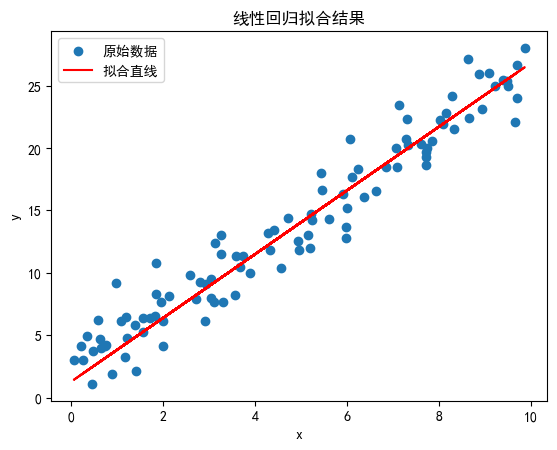

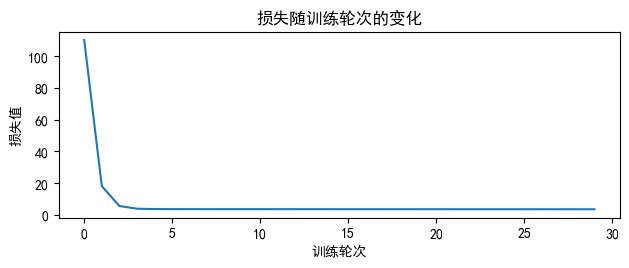

In [ ]:
# 用pytorch实现线性回归
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
#pyplot隐式实例化,Matplotlib 在背后自动创建并管理了两个核心对象：画布和子图。
# plt 本身并不是一个 “实例对象”，而是一个 模块（module），它内部维护了一套 “全局状态管理机制”


# 设置中文字体，解决中文显示问题
plt.rcParams["font.family"] = ["SimHei"]
# 解决负号显示问题
plt.rcParams['axes.unicode_minus'] = False # 部分中文字体对 Unicode 负号字符的支持不完善，导致负号无法正确渲染。默认值为 True，表示使用 Unicode 编码的负号（−，U+2212）。
# 设置为 False 后，会改用 ASCII 编码的减号（-，U+002D），这种符号在几乎所有字体中都能正常显示，避免了负号乱码问题。

# 设置随机种子，保证结果可复现
torch.manual_seed(42) #设置后，每次运行程序时，PyTorch 生成的随机数序列会完全相同。
np.random.seed(42) #为 NumPy 库设置随机种子

# 1. 生成模拟数据
# 真实的权重和偏置
true_w = 2.5
true_b = 1.8

# 生成输入数据x,将 NumPy 数组（numpy.ndarray）转为 PyTorch 张量（torch.Tensor）
# torch.tensor 是 PyTorch 中用于创建 “张量（Tensor）” 的基础函数。Tensor是 PyTorch 处理数据的基本单位（类似 NumPy 中的 ndarray）。
# 它不仅能存储数值，还支持 自动微分（反向传播的核心）、GPU 加速计算等深度学习必需的功能 
x = torch.tensor(np.random.rand(100, 1) * 10, dtype=torch.float32)

# 生成带有噪声的目标值y。所有参与运算的元素最终都会统一为 torch.float32 类型的张量。
# 广播机制！形状不匹配但 “兼容” 的张量，能进行 element-wise（逐元素）运算
# yTorch 的广播是「逻辑上的扩展」，不会实际复制数据，只是在计算时 “虚拟地” 将标量的数值应用到每个位置
y = true_w * x + true_b + torch.tensor(np.random.randn(100, 1) * 2, dtype=torch.float32)

# 2. 定义线性回归模型
# nn.Module 是 PyTorch 中 所有神经网络模型的 “基类”（可以理解为 “模板”），它封装了模型训练所需的核心功能，比如：
#自动管理模型中的可训练参数（如线性回归的 w 和 b）；支持前向传播（forward 方法）的调用逻辑；
# 提供参数初始化、模型保存 / 加载、GPU 迁移等工具函数；配合自动微分（autograd）实现反向传播时的梯度计算。
# nn指神经网络
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        # 定义一个线性层，输入维度1，输出维度1
        self.linear = nn.Linear(in_features=1, out_features=1)
    
    def forward(self, x):
        # 前向传播
        return self.linear(x)

# 实例化模型
model = LinearRegressionModel()

# 3. 定义损失函数和优化器
# 使用均方误差作为损失函数
criterion = nn.MSELoss()

# 使用随机梯度下降(SGD)作为优化器，学习率0.01
# 每次更新参数前，不从全部样本中计算梯度，而是随机挑选部分样本。后面可以指定选取全部。
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# 4. 训练模型
epochs = 30  # 训练轮次
losses = []  # 记录损失变化
for epoch in range(epochs):
    # 前向传播：计算模型预测值
    y_pred = model(x) # 全量
    
    # 计算损失
    loss = criterion(y_pred, y)
    losses.append(loss.item())
    
    # 反向传播和优化
    optimizer.zero_grad()  # 清零梯度
    # 在 PyTorch 中，当调用 loss.backward() 时，计算出的梯度会自动累加到参数的 .grad 属性中（而不是直接覆盖）
    # 自动累加可以节约显存
    loss.backward()        # 反向传播计算梯度
    optimizer.step()       # 更新参数
    
    # 每100轮打印一次损失和参数值
    if (epoch + 1) % 10 == 0:
        # 获取当前的权重和偏置
        w, b = model.parameters()
        # f-string 是 Python 3.6+ 引入的字符串格式化方式，以 f 或 F 开头，字符串内部通过 {变量/表达式} 嵌入动态内容
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, w: {w.item():.4f}, b: {b.item():.4f}')

# 5. 输出最终学习到的参数和真实参数
# str.format() 是 Python 中用于字符串格式化的经典方法（适用于所有 Python 3 版本，兼容性比 f-string 更广）。其核心逻辑是：
#先定义一个「带占位符的字符串模板」（占位符用 {} 表示）；
# 调用 format() 方法，传入需要填充到占位符的变量；变量会按顺序（或按占位符名称）替换占位符，生成最终的格式化字符串。
print("\n真实参数: w = {:.4f}, b = {:.4f}".format(true_w, true_b))
w_final, b_final = model.parameters()
print("学习到的参数: w = {:.4f}, b = {:.4f}".format(w_final.item(), b_final.item()))

# 6. 可视化结果
# 生成预测值
# .detach()：将张量从计算图中 “剥离”（PyTorch 的张量默认会记录计算历史用于反向传播），此时后续转换为 NumPy 数组时避免因关联计算图而报错。
# .numpy()：将 PyTorch 张量转换为 NumPy 数组（numpy.ndarray），因为 Matplotlib 绘图（plt）仅支持 NumPy 数组或 Python 基本类型的数据绘图。
y_pred = model(x).detach().numpy()

plt.scatter(x.numpy(), y.numpy(), label='原始数据') #Matplotlib 中绘制散点图的函数，用于展示原始数据的分布。
plt.plot(x.numpy(), y_pred, 'r-', label='拟合直线') #plt.plot：Matplotlib 中绘制线图的函数，用于展示模型的预测结果（拟合直线）。
plt.xlabel('x')
plt.ylabel('y')
plt.title('线性回归拟合结果')
plt.legend() #显示图例（legend）
plt.show()

plt.subplot(2,1 , 2) # 是 Matplotlib 中用于创建子图（Subplot） 的核心函数，作用是在同一个画布（Figure）中划分出多个独立的绘图区域，
#并指定当前要绘制的 “子图位置”。1,2,2指 划分为1行2列,当前操作子图编号2
plt.plot(range(epochs), losses)
plt.xlabel('训练轮次')
plt.ylabel('损失值')
plt.title('损失随训练轮次的变化')
plt.tight_layout()
plt.show()

生成的数据 - 真实权重: [ 4.96714153 -1.38264301  6.47688538], 真实偏置: 7.62

初始成本: 56.09
初始参数下的dj_db: -7.2001
初始参数下的dj_dw: [-3.89509922  2.1378427  -4.6795502 ]

开始梯度下降...
迭代次数    0: 成本    55.62
迭代次数  100: 成本    24.62
迭代次数  200: 成本    11.52
迭代次数  300: 成本     5.90
迭代次数  400: 成本     3.45
迭代次数  500: 成本     2.38
迭代次数  600: 成本     1.90
迭代次数  700: 成本     1.68
迭代次数  800: 成本     1.58
迭代次数  900: 成本     1.54

梯度下降找到的参数 - b: 7.78, w: [ 5.17080554 -1.43021924  6.01866073]
真实参数 - b: 7.62, w: [ 4.96714153 -1.38264301  6.47688538]

部分预测结果与真实值对比:
预测值: 16.41, 真实值: 16.96
预测值: 15.69, 真实值: 15.82
预测值: 7.51, 真实值: 10.08
预测值: -3.03, 真实值: -4.33
预测值: -3.37, 真实值: -2.64


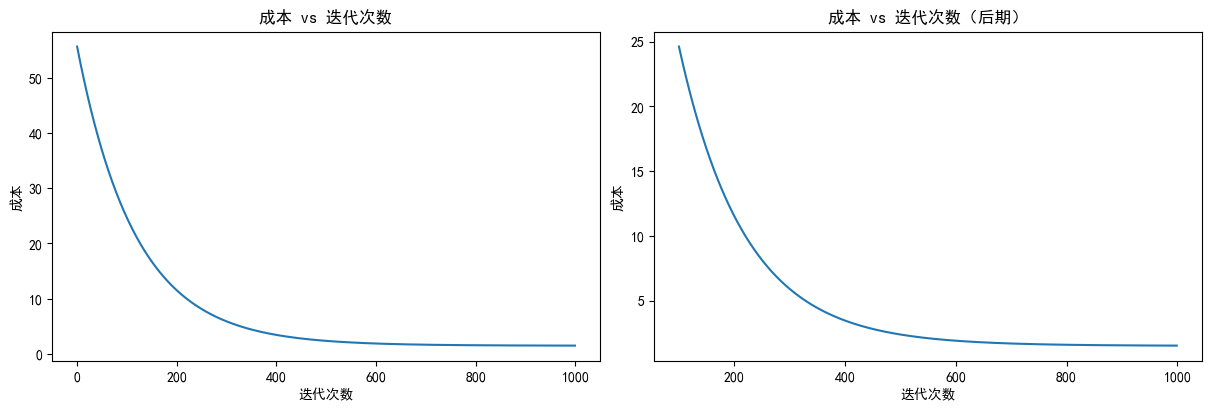

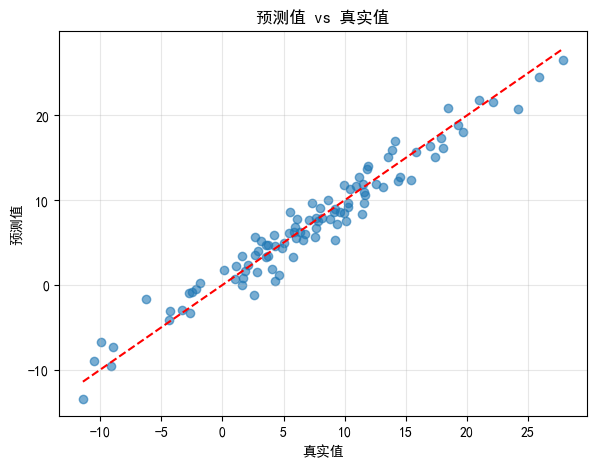

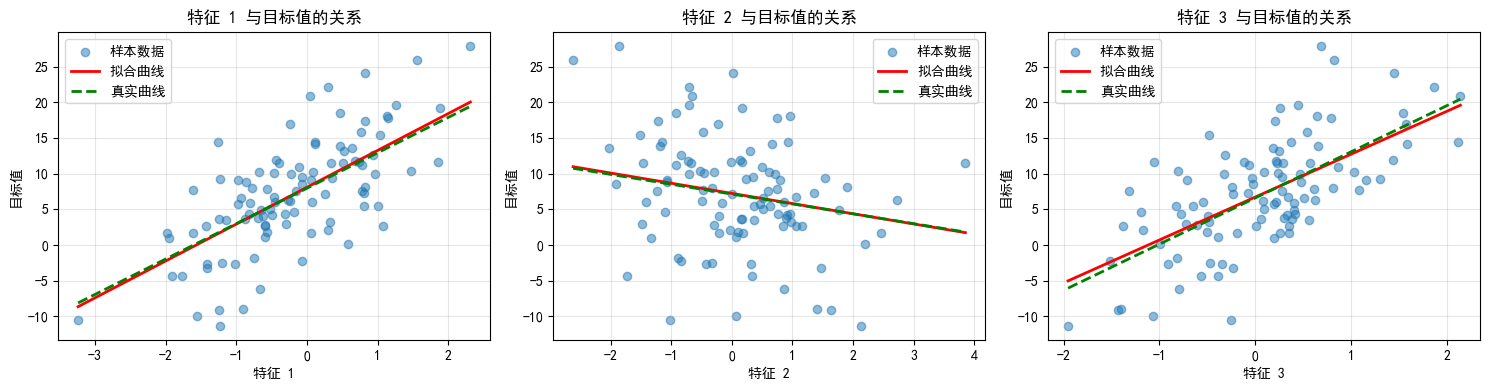

In [ ]:
# 用纯numpy实现线性回归
import copy
import math
import numpy as np
import matplotlib.pyplot as plt
# 设置中文字体，解决中文显示问题
plt.rcParams["font.family"] = ["SimHei"]
# 解决负号显示问题
plt.rcParams['axes.unicode_minus'] = False 


# 生成示例数据（模拟真实世界的多特征数据集）
def generate_sample_data(m=100, n=3, random_state=42):
    """生成用于测试的样本数据
    
    Args:
        m: 样本数量
        n: 特征数量
        random_state: 随机种子，保证结果可复现
        
    Returns:
        X: 特征矩阵 (m, n)
        y: 目标值向量 (m,)
        true_w: 真实权重，用于生成数据
        true_b: 真实偏置，用于生成数据
    """
    np.random.seed(random_state)
    
    # 生成真实参数
    true_w = np.random.randn(n) * 10  # 随机权重
    true_b = np.random.randn() * 5    # 随机偏置
    
    # 生成特征数据（正态分布）
    X = np.random.randn(m, n)
    
    # 生成目标值，加入一些噪声
    y = np.dot(X, true_w) + true_b + np.random.randn(m) * 2
    
    return X, y, true_w, true_b

def compute_cost(X, y, w, b): 
    """
    计算线性回归的成本（均方误差损失）
    
    Args:
      X (ndarray (m,n)): 输入数据，m个样本，每个样本有n个特征
      y (ndarray (m,)) : 目标值向量
      w (ndarray (n,)) : 模型权重参数
      b (scalar)       : 模型偏置参数
      
    Returns:
      cost (scalar): 计算得到的成本值
    """
    m = X.shape[0]  # 获取样本数量
    cost = 0.0
    
    for i in range(m):                                
        # 计算第i个样本的预测值
        f_wb_i = np.dot(X[i], w) + b          
        # 累加平方误差
        cost = cost + (f_wb_i - y[i])**2       
    # 计算平均成本（除以2m是为了后续求导方便）
    cost = cost / (2 * m)                     
    
    return cost

def compute_gradient(X, y, w, b): 
    """
    计算线性回归的梯度
    
    Args:
      X (ndarray (m,n)): 输入数据，m个样本，每个样本有n个特征
      y (ndarray (m,)) : 目标值向量
      w (ndarray (n,)) : 模型权重参数
      b (scalar)       : 模型偏置参数
      
    Returns:
      dj_dw (ndarray (n,)): 成本函数对每个权重w的偏导数（梯度）
      dj_db (scalar):       成本函数对偏置b的偏导数（梯度）
    """
    m, n = X.shape  # m是样本数，n是特征数
    dj_dw = np.zeros((n,))  # 初始化权重梯度为0
    dj_db = 0.0             # 初始化偏置梯度为0

    for i in range(m):                             
        # 计算第i个样本的预测误差
        err = (np.dot(X[i], w) + b) - y[i]   
        
        # 计算每个权重的梯度
        for j in range(n):                         
            # 成本函数对w_j的偏导数为：(err)·X[i,j]
            dj_dw[j] = dj_dw[j] + err * X[i, j]    
        
        # 计算偏置的梯度
        dj_db = dj_db + err                        
    
    # 求平均梯度
    dj_dw = dj_dw / m                                
    dj_db = dj_db / m                                
    
    return dj_db, dj_dw

def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters): 
    """
    执行批量梯度下降算法来学习模型参数，通过num_iters次迭代更新参数，学习率为alpha
    
    Args:
      X (ndarray (m,n))   : 输入数据，m个样本，每个样本有n个特征
      y (ndarray (m,))    : 目标值向量
      w_in (ndarray (n,)) : 初始权重参数
      b_in (scalar)       : 初始偏置参数
      cost_function       : 计算成本的函数
      gradient_function   : 计算梯度的函数
      alpha (float)       : 学习率
      num_iters (int)     : 迭代次数
      
    Returns:
      w (ndarray (n,)) : 更新后的权重参数
      b (scalar)       : 更新后的偏置参数
      J_history: 每次迭代的成本值，用于后续可视化
      """
    
    # 存储每次迭代的成本值，用于后续绘图分析
    J_history = []
    # 深拷贝初始参数，避免修改外部变量
    w = copy.deepcopy(w_in)
    b = b_in
    
    for i in range(num_iters):
        # 计算当前参数下的梯度
        dj_db, dj_dw = gradient_function(X, y, w, b)
        
        # 使用梯度下降更新参数
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
      
        # 保存当前迭代的成本值（防止过多迭代导致内存耗尽）
        if i < 100000:
            J_history.append(cost_function(X, y, w, b))

        # 定期打印成本值，监控训练进度
        # 总共打印10次，或者如果迭代次数少于10，则每次迭代都打印
        if i % math.ceil(num_iters / 10) == 0:
            print(f"迭代次数 {i:4d}: 成本 {J_history[-1]:8.2f}")
        
    return w, b, J_history  # 返回最终参数和成本历史

def plot_regression_results(X, y, w, b, true_w, true_b):
    """
    绘制回归结果的可视化图表
    
    Args:
        X: 特征矩阵
        y: 目标值向量
        w: 学习到的权重
        b: 学习到的偏置
        true_w: 真实权重
        true_b: 真实偏置
    """
    # 1. 绘制预测值与真实值的对比
    y_pred = np.dot(X, w) + b
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    plt.scatter(y, y_pred, alpha=0.6)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 理想的预测线（y=x）
    plt.xlabel('真实值')
    plt.ylabel('预测值')
    plt.title('预测值 vs 真实值')
    plt.grid(True, alpha=0.3)
    
    # 2. 为每个特征绘制其与目标值的关系及拟合曲线
    n_features = X.shape[1]
    fig, axes = plt.subplots(1, n_features, figsize=(5 * n_features, 4))
    if n_features == 1:
        axes = [axes]  # 处理单特征的情况
    
    # 计算每个特征的平均值，用于固定其他特征
    X_mean = np.mean(X, axis=0)
    
    for i, ax in enumerate(axes):
        # 提取当前特征
        x_feature = X[:, i]
        
        # 创建特征范围，用于绘制平滑曲线
        x_range = np.linspace(x_feature.min(), x_feature.max(), 100)
        
        # 固定其他特征为平均值，只变化当前特征
        X_fixed = np.tile(X_mean, (100, 1))
        X_fixed[:, i] = x_range
        
        # 计算预测值（学习到的模型）
        y_pred_range = np.dot(X_fixed, w) + b
        
        # 计算真实值（生成数据的模型）
        y_true_range = np.dot(X_fixed, true_w) + true_b
        
        # 绘制散点图和拟合曲线
        ax.scatter(x_feature, y, alpha=0.5, label='样本数据')
        ax.plot(x_range, y_pred_range, 'r-', linewidth=2, label='拟合曲线')
        ax.plot(x_range, y_true_range, 'g--', linewidth=2, label='真实曲线')
        ax.set_xlabel(f'特征 {i+1}')
        ax.set_ylabel('目标值')
        ax.set_title(f'特征 {i+1} 与目标值的关系')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 主程序：执行多维度线性回归
if __name__ == "__main__":
    # 1. 生成样本数据
    # 生成100个样本，每个样本有3个特征
    X_train, y_train, true_w, true_b = generate_sample_data(m=100, n=3)
    print(f"生成的数据 - 真实权重: {true_w}, 真实偏置: {true_b:.2f}")
    
    # 2. 初始化模型参数
    initial_w = np.zeros_like(true_w)  # 初始权重设为0
    initial_b = 0.0                    # 初始偏置设为0
    
    # 3. 计算初始成本和梯度（测试用）
    initial_cost = compute_cost(X_train, y_train, initial_w, initial_b)
    print(f"\n初始成本: {initial_cost:.2f}")
    
    tmp_dj_db, tmp_dj_dw = compute_gradient(X_train, y_train, initial_w, initial_b)
    print(f"初始参数下的dj_db: {tmp_dj_db:.4f}")
    print(f"初始参数下的dj_dw: {tmp_dj_dw}")
    
    # 4. 设置梯度下降的超参数
    iterations = 1000    # 迭代次数
    alpha = 5.0e-3       # 学习率（根据实际数据调整）
    
    # 5. 运行梯度下降算法
    print("\n开始梯度下降...")
    w_final, b_final, J_hist = gradient_descent(
        X_train, y_train, initial_w, initial_b,
        compute_cost, compute_gradient, 
        alpha, iterations
    )
    
    # 6. 输出训练结果
    print(f"\n梯度下降找到的参数 - b: {b_final:0.2f}, w: {w_final}")
    print(f"真实参数 - b: {true_b:0.2f}, w: {true_w}")
    
    # 7. 打印部分预测结果与真实值的对比
    print("\n部分预测结果与真实值对比:")
    m, _ = X_train.shape
    # 打印前5个样本的预测结果
    for i in range(min(5, m)):
        prediction = np.dot(X_train[i], w_final) + b_final
        print(f"预测值: {prediction:0.2f}, 真实值: {y_train[i]:0.2f}")
    
    # 8. 绘制成本随迭代次数变化的曲线
    fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
    
    # 绘制完整的成本曲线
    ax1.plot(J_hist)
    ax1.set_title("成本 vs 迭代次数")
    ax1.set_ylabel('成本')
    ax1.set_xlabel('迭代次数')
    
    # 绘制后期的成本曲线（从第100次迭代开始），更清晰地看到收敛情况
    if len(J_hist) > 100:
        ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
        ax2.set_title("成本 vs 迭代次数（后期）")
        ax2.set_ylabel('成本')
        ax2.set_xlabel('迭代次数')
    else:
        ax2.plot(J_hist)
        ax2.set_title("成本 vs 迭代次数")
        ax2.set_ylabel('成本')
        ax2.set_xlabel('迭代次数')
    
    plt.show()
    
    # 9. 绘制最终的回归函数曲线和拟合效果
    plot_regression_results(X_train, y_train, w_final, b_final, true_w, true_b)


原始特征形状: (80, 1)
多项式特征形状: (80, 2)
前5个样本的多项式特征:
[[ 0.33  0.11]
 [ 2.33  5.44]
 [-1.42  2.03]
 [-0.45  0.21]
 [ 1.18  1.4 ]]

模型参数:
偏置 b = 1.91
权重 w = [1.01 0.51]

训练集MSE: 0.2151
测试集MSE: 0.1549


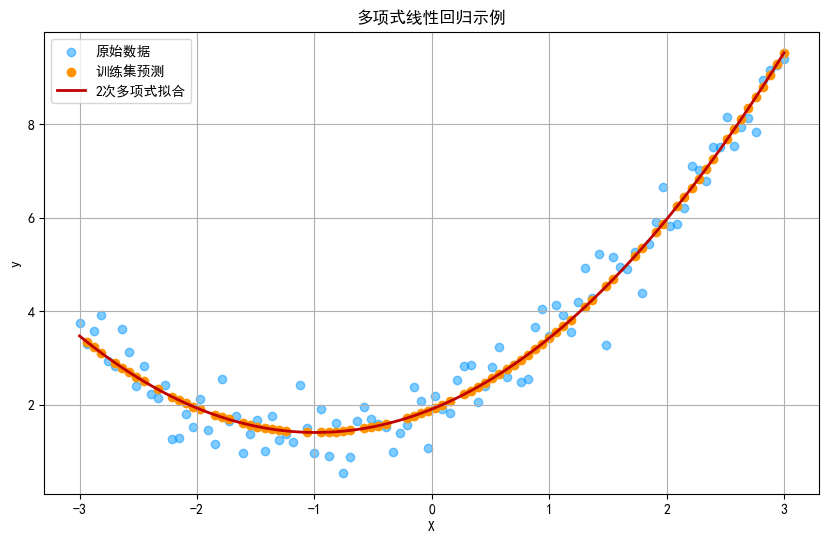

In [ ]:
# 用sklearn实现多项式线性回归
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 设置打印精度
np.set_printoptions(precision=2)

# 定义颜色
dlblue = '#0096ff'; dlorange = '#FF9300'; dldarkred='#C00000'; 
dlmagenta='#FF40FF'; dlpurple='#7030A0'; 

# 1. 生成示例数据
np.random.seed(42)
X = np.linspace(-3, 3, 100).reshape(-1, 1)  # 特征
y = 2 + X + 0.5 * X**2 + np.random.normal(0, 0.5, size=X.shape)  # 二次函数关系 + 噪声
y = y.ravel()  # 将y转换为一维数组，避免后续问题

# 2. 划分训练集和测试集，测试集占20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 创建多项式特征 (这里选择2次多项式)
degree = 2  # 多项式阶数
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)  # 转换训练集特征
X_test_poly = poly.transform(X_test)        # 转换测试集特征

print(f"原始特征形状: {X_train.shape}")
print(f"多项式特征形状: {X_train_poly.shape}")
print("前5个样本的多项式特征:")
print(X_train_poly[:5])

# 4. 训练多项式线性回归模型
model = LinearRegression()
model.fit(X_train_poly, y_train)  #自动计算出最优的模型参数

# 5. 获取模型参数，确保是标量
b = model.intercept_  # 偏置
w = model.coef_   # 系数
# 如果b是数组，取第一个元素
if isinstance(b, np.ndarray):
    b = b[0]

print(f"\n模型参数:")
print(f"偏置 b = {b:.2f}")
print(f"权重 w = {w}")

# 6. 模型预测与评估
y_pred_train = model.predict(X_train_poly)
y_pred_test = model.predict(X_test_poly)

train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
print(f"\n训练集MSE: {train_mse:.4f}")
print(f"测试集MSE: {test_mse:.4f}")

# 7. 可视化结果
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color=dlblue, alpha=0.5, label='原始数据')
plt.scatter(X_train, y_pred_train, color=dlorange, label='训练集预测')
plt.plot(X, model.predict(poly.transform(X)), color=dldarkred, linewidth=2, label=f'{degree}次多项式拟合')
plt.xlabel('X')
plt.ylabel('y')
plt.title('多项式线性回归示例')
plt.legend()
plt.grid(True)
plt.show()
    